In [251]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os


In [252]:
plt.style.use("seaborn-v0_8")

In [253]:
# Download latest version
path = kagglehub.dataset_download("mustafasinanovic/sarajevo-flats")

print("Path to dataset files:", path)

Path to dataset files: /Users/emrearapcic-uevak/.cache/kagglehub/datasets/mustafasinanovic/sarajevo-flats/versions/1


In [254]:
filepath = os.path.join(path, "sarajevo_flats_olx.csv")
apartments = pd.read_csv(filepath)
apartments.head()

,title,url,price_numeric,municipality,condition,ad_type,property_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
0,Stan Apartman - [Iznajmljivanje],https://olx.ba/artikal/71698283,60.0,Sarajevo - Novi Grad,Novogradnja,Iznajmljivanje,Apartman,2.0,46.0,Namješten,7,Centralno (gradsko),1.304348,NaN,NaN
1,Stan Sarajevo - Novo Sarajevo - [Iznajmljivanje],https://olx.ba/artikal/71573692,80.0,Sarajevo - Novo Sarajevo,Renoviran,Iznajmljivanje,Apartman,2.0,62.0,Namješten,16,Centralno (gradsko),1.290323,43.850305,18.374470
2,Garaza - Nova Vogosca - 20 m2 - [Iznajmljivanje],https://olx.ba/artikal/70756410,100.0,Vogošća,Novogradnja,Iznajmljivanje,Stan,2.0,20.0,Namješten,-1,Centralno (Kotlovnica),5.000000,43.901206,18.354117
3,Panorama View Apartman Bjelasnica (Rent) - [Iz...,https://olx.ba/artikal/71554658,160.0,Trnovo,Novogradnja,Iznajmljivanje,Apartman,2.0,50.0,Namješten,0,Struja,3.200000,43.714503,18.288786
4,Stanovi i apartmani Sarajevo - Novi Grad - [Iz...,https://olx.ba/artikal/71474528,200.0,Sarajevo - Novi Grad,Dobro stanje,Iznajmljivanje,Apartman,1.0,30.0,Namješten,1,Centralno (Kotlovnica),6.666667,43.800453,18.246421


In [255]:
apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          1806 non-null   object 
 1   url            1806 non-null   object 
 2   price_numeric  1428 non-null   float64
 3   municipality   1806 non-null   object 
 4   condition      1806 non-null   object 
 5   ad_type        1806 non-null   object 
 6   property_type  1806 non-null   object 
 7   rooms          1664 non-null   float64
 8   square_m2      1806 non-null   float64
 9   equipment      1806 non-null   object 
 10  level          1806 non-null   object 
 11  heating        1806 non-null   object 
 12  price_per_m2   1428 non-null   float64
 13  latitude       1175 non-null   float64
 14  longitude      1175 non-null   float64
dtypes: float64(6), object(9)
memory usage: 211.8+ KB


In [256]:
# Drop unneeded columns
apartments.drop(labels=["title", "url"], axis='columns', inplace=True)

In [257]:
for column, column_type in apartments.dtypes.items():
  if column_type == 'object':
    print(f"----------------------------------------{column}----------------------------------------")
    print(apartments[column].unique())

----------------------------------------municipality----------------------------------------
['Sarajevo - Novi Grad' 'Sarajevo - Novo Sarajevo' 'Vogošća' 'Trnovo'
 'Sarajevo - Centar' 'Sarajevo - Stari Grad' 'Ilidža' 'Ilijaš' 'Hadžići']
----------------------------------------condition----------------------------------------
['Novogradnja' 'Renoviran' 'Dobro stanje' 'Parcijalno renoviran'
 'Za renoviranje' 'Apartman' 'U izgradnji']
----------------------------------------ad_type----------------------------------------
['Iznajmljivanje' 'Prodaja']
----------------------------------------property_type----------------------------------------
['Apartman' 'Stan']
----------------------------------------equipment----------------------------------------
['Namješten' 'Nenamješten' 'Polunamješten']
----------------------------------------level----------------------------------------
['7' '16' '-1' '0' '1' '3' '2' '4' '5' '14' '6' '10' '13' '15' '-2' '8'
 '11' '9' '19' '12' '18' '17' '20+' '-3']

# Rename the categorical data into english and transform the type from object to category for more efficient memory usage

In [258]:
condition_map = {
    "Novogradnja": "New Build",
    "Renoviran": "Renovated",
    "Dobro stanje": "Good Condition",
    "Parcijalno renoviran": "Partially Renovated",
    "Za renoviranje": "Needs Renovation",
    "Apartman": "Apartment",
    "U izgradnji": "Under Construction",
}

ad_type_map = {
    "Iznajmljivanje": "Rent",
    "Prodaja": "Sale",
}

property_type_map = {
    "Apartman": "Apartment",
    "Stan": "Flat",
}

equipment_map = {
    "Namješten": "Furnished",
    "Nenamješten": "Unfurnished",
    "Polunamješten": "Semi-Furnished",
}

heating_map = {
    "Centralno (gradsko)": "District Heating",
    "Centralno (Kotlovnica)": "Central (Boiler Room)",
    "Struja": "Electric Heating",
    "Centralno (Plin)": "Central Gas Heating",
    "Plin": "Gas Heating",
    "Drva": "Wood Heating",
    "Ostalo": "Other",
}

apartments.replace(to_replace={
  "condition" : condition_map,
  "heating" : heating_map,
  "property_type" : property_type_map,
  "equipment" : equipment_map,
  "ad_type" : ad_type_map,
}, inplace=True)

In [259]:
apartments['municipality'] =  apartments['municipality'].astype('category')
apartments['condition'] = apartments['condition'].astype('category')
apartments['heating'] = apartments['heating'].astype('category')
apartments['property_type'] = apartments['property_type'].astype('category')
apartments['equipment'] = apartments['equipment'].astype('category')
apartments['ad_type'] =  apartments['ad_type'].astype('category')

In [260]:
apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   price_numeric  1428 non-null   float64 
 1   municipality   1806 non-null   category
 2   condition      1806 non-null   category
 3   ad_type        1806 non-null   category
 4   property_type  1806 non-null   category
 5   rooms          1664 non-null   float64 
 6   square_m2      1806 non-null   float64 
 7   equipment      1806 non-null   category
 8   level          1806 non-null   object  
 9   heating        1806 non-null   category
 10  price_per_m2   1428 non-null   float64 
 11  latitude       1175 non-null   float64 
 12  longitude      1175 non-null   float64 
dtypes: category(6), float64(6), object(1)
memory usage: 110.9+ KB


# Change levels to be a numeric type

Also take care of the 20+ values by turning them into 20 since apartments in Sarajevo RARELY go that much higher and majority of
apartments really high up usually go up till the 22nd floor

In [261]:
apartments.replace(to_replace={
  "level" : {
    "20+" : 20
  }
}, inplace=True)

apartments['level'] = apartments['level'].astype("int32")

In [262]:
apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   price_numeric  1428 non-null   float64 
 1   municipality   1806 non-null   category
 2   condition      1806 non-null   category
 3   ad_type        1806 non-null   category
 4   property_type  1806 non-null   category
 5   rooms          1664 non-null   float64 
 6   square_m2      1806 non-null   float64 
 7   equipment      1806 non-null   category
 8   level          1806 non-null   int32   
 9   heating        1806 non-null   category
 10  price_per_m2   1428 non-null   float64 
 11  latitude       1175 non-null   float64 
 12  longitude      1175 non-null   float64 
dtypes: category(6), float64(6), int32(1)
memory usage: 103.9 KB


# Check Categorical Data (Class) Distributions

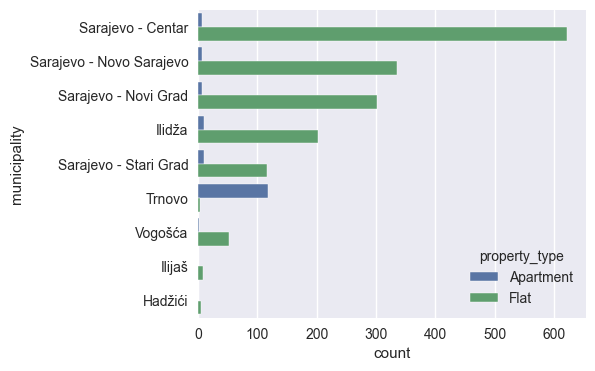

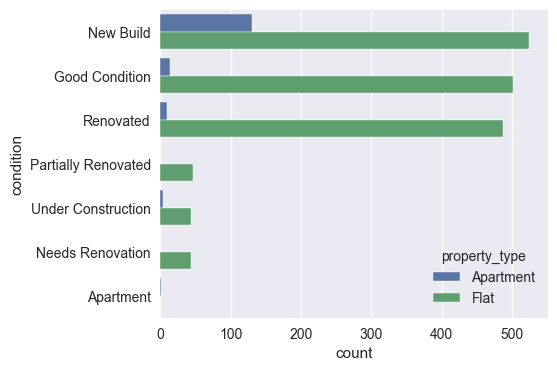

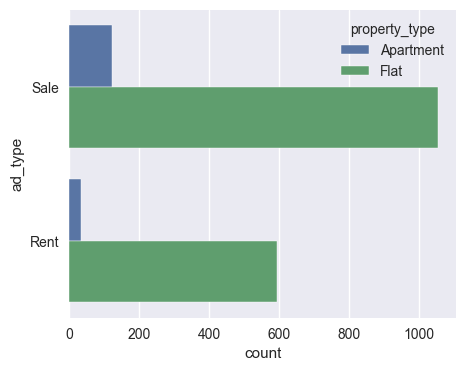

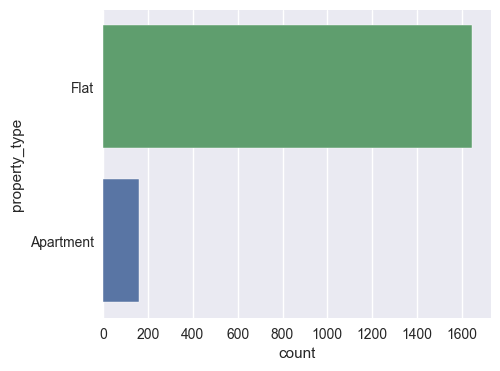

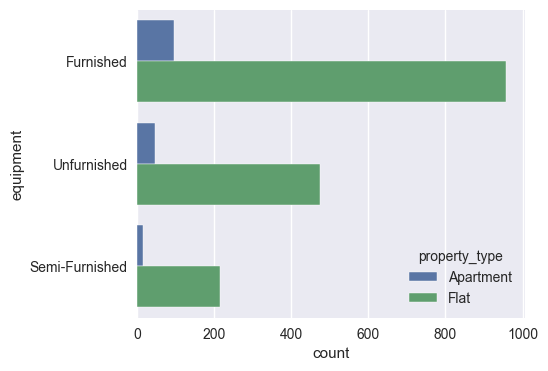

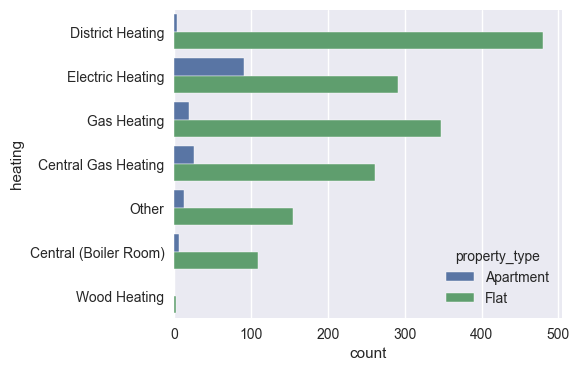

In [263]:
for column, column_type in apartments.dtypes.items():
  if column_type  == 'category':
    plt.figure(figsize=(5, 4))
    sns.countplot(data=apartments, y = column, order=apartments[column].value_counts().index.values, hue="property_type")



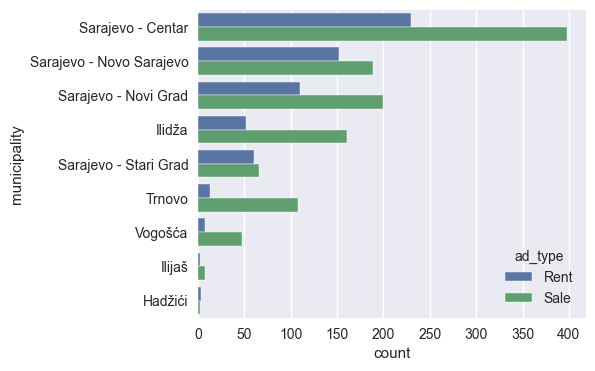

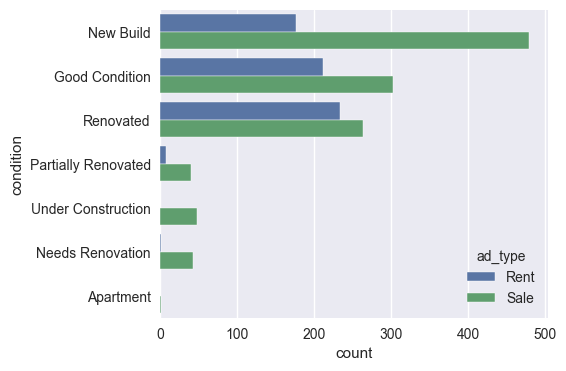

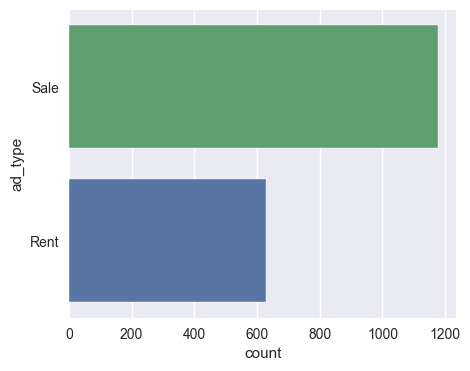

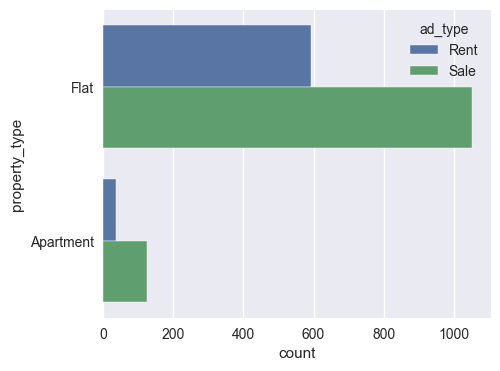

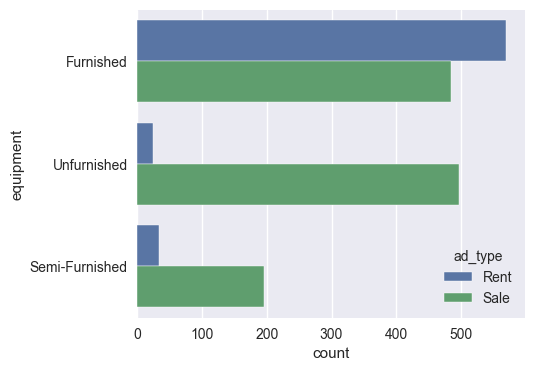

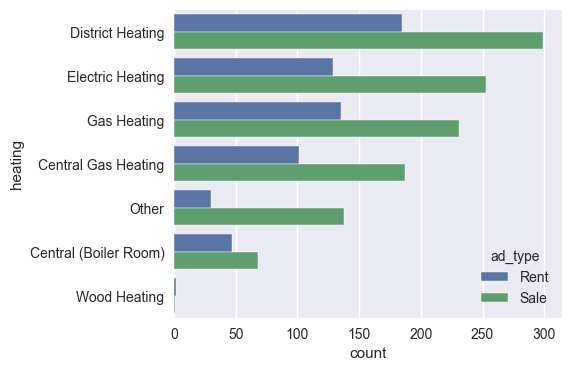

In [264]:
for column, column_type in apartments.dtypes.items():
  if column_type  == 'category':
    plt.figure(figsize=(5, 4))
    sns.countplot(data=apartments, y = column, order=apartments[column].value_counts().index.values, hue="ad_type")

<Axes: xlabel='count', ylabel='property_type'>

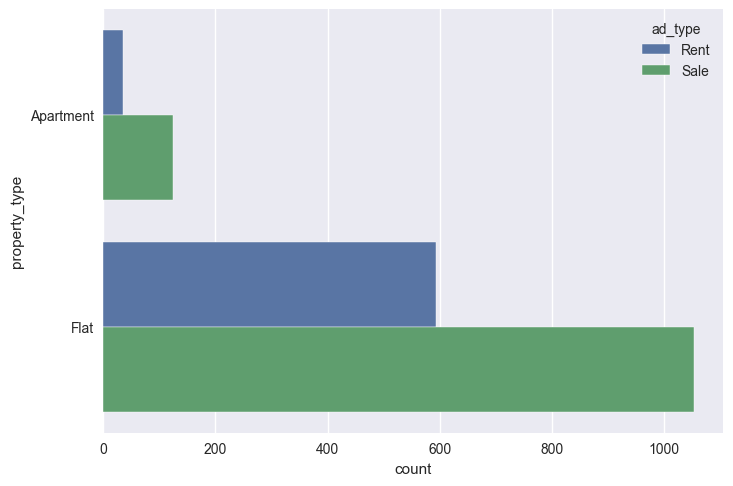

In [265]:
sns.countplot(data=apartments, y = "property_type", hue="ad_type")

Text(0.5, 0.98, 'Equipment distribution')

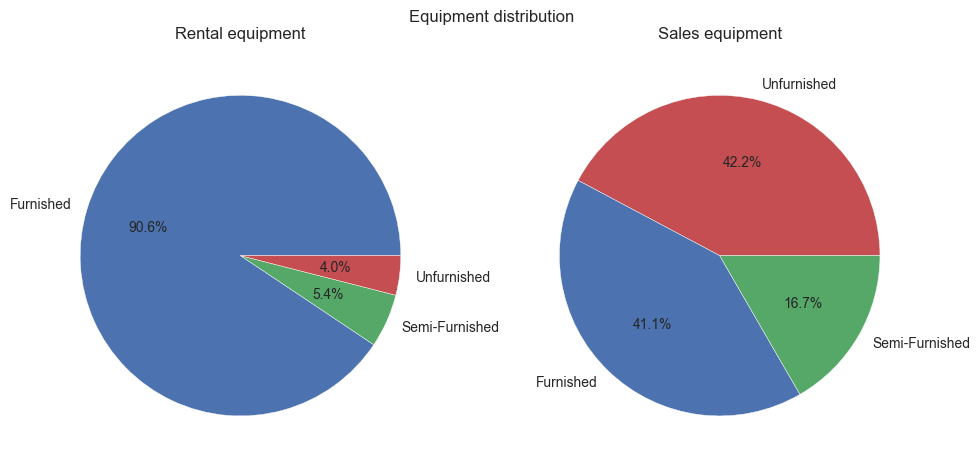

In [266]:
rentals = apartments[apartments['ad_type'] == 'Rent']
sales = apartments[apartments['ad_type'] == 'Sale']

rental_equipment =  rentals['equipment'].value_counts()
sales_equipment = sales['equipment'].value_counts()


default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
category_colors = {
  'Furnished' : default_colors[0],
  'Semi-Furnished' : default_colors[1],
  'Unfurnished' : default_colors[2]
}


plt.subplots(nrows = 1, ncols = 2, figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(x = rental_equipment, labels=rental_equipment.index.values, autopct='%.1f%%', colors=[category_colors[cat] for cat in rental_equipment.index.values])
plt.title('Rental equipment', pad=12)

plt.subplot(1, 2, 2)
plt.pie(x = sales_equipment, labels = sales_equipment.index.values, autopct='%.1f%%', colors=[category_colors[cat] for cat in sales_equipment.index.values])
plt.title('Sales equipment', pad=12)

plt.tight_layout()
plt.suptitle('Equipment distribution')

In [267]:
apartments[(apartments['condition'] == 'Apartment') | (apartments['heating'] == 'Wood Heating')]

,price_numeric,municipality,condition,ad_type,property_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
13,300.0,Sarajevo - Stari Grad,Good Condition,Rent,Flat,1.0,35.00,Furnished,0,Wood Heating,8.571429,43.863231,18.435523
60,500.0,Ilidža,New Build,Rent,Flat,3.0,90.00,Furnished,1,Wood Heating,5.555556,43.875132,18.202102
535,120000.0,Ilidža,Good Condition,Sale,Flat,3.0,120.00,Furnished,0,Wood Heating,1000.000000,43.830618,18.307736
628,197184.0,Trnovo,Apartment,Sale,Apartment,2.0,37.92,Unfurnished,2,Electric Heating,5200.000000,43.709897,18.284125


# What can we see from the distribution of categorical data?

Well here are some key-notes
1. When it comes to differentiation of the apartments data with respect to the `ad_type` feature, there seems to be way more `"Flats"` then `"Apartments"` but this might be a useless feature as there isn't really a real difference between an `Apartment` and a `Flat` so this might be droppable
2. When it comes to `condition` there seems to one outlier which marked `condition` as `apartment` which can be removed
3. When it comes to `heating` There are only three apartments marked to have `Wood Heating` which isn't a lot and I find it to be better to remove them rather than to train the ML model on them
4. Otherwise, 'heating' is pretty balanced considering we have way less `Rentals` then `Apartments on Sale` in the data.
5. When it comes to `condition` again, there are no `Rentals` that are marked as `Under Construction` or `Need Renovations` which makes sense but is an important thing to mention
6. When it comes to `equipment`  majority of `Rentals` already come furnished which makes sense, whilst for `Apartments on Sale` that different categories are well-balanced except the `Semi-Furnished` being somewhat miss represented
7. When it comes to `municipality` dropping `Ilijas` and `Hadzici` for now seems to be the go since they make a tiny portion of the data and will make it hard to train the ML model well on them. And for `Vogosca` and `Trnovo` they have a small number of `Rentals` but it can be worked with
8. As mentioned in previously it is a really nice idea to replace `municipality` with information regarding the general location of the apartments however `municipalities` still offer some information when it comes to legal standing that could potentially play a role in the price

# Checking Distribution of Numeric Features

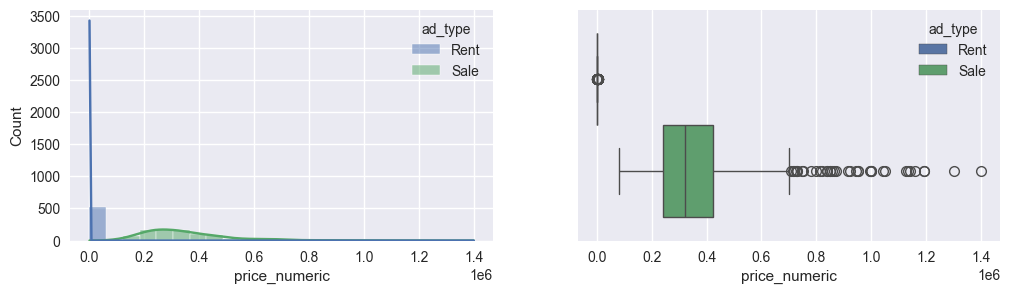

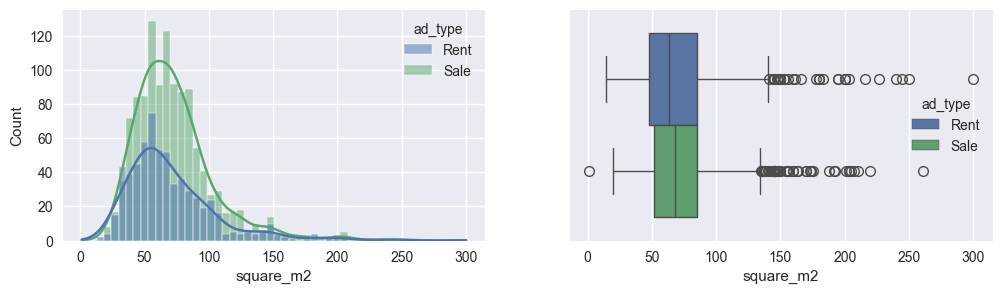

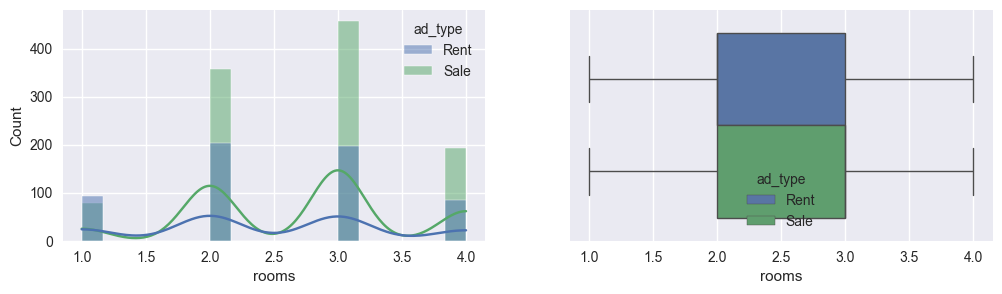

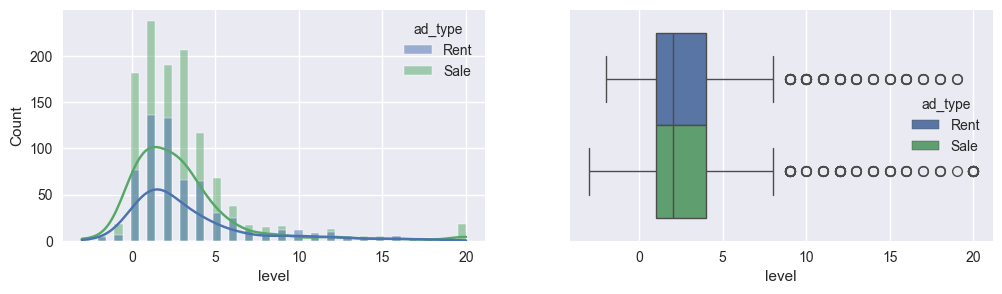

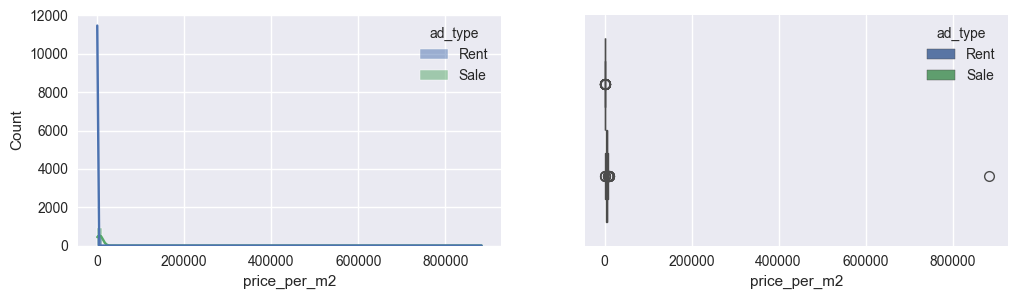

In [268]:
numeric_features = ['price_numeric', 'square_m2', 'rooms', 'level', "price_per_m2"]

for feature in numeric_features:
  plt.subplots(nrows = 1, ncols=2, figsize=(12, 3), sharex=True)

  plt.subplot(1,2,1)
  sns.histplot(data=apartments, x=feature, hue='ad_type', kde=True)

  plt.subplot(1,2,2)
  sns.boxplot(data=apartments, x=feature, hue='ad_type')

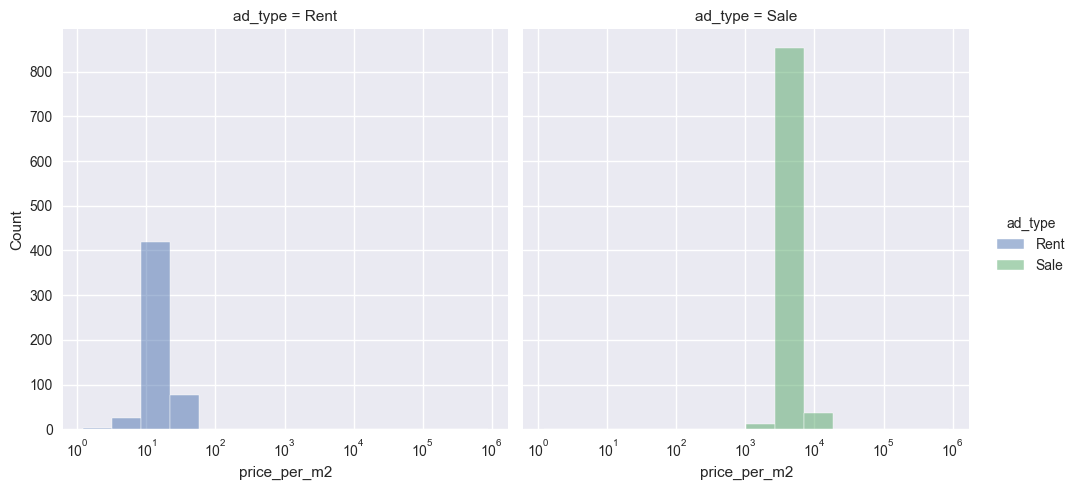

In [269]:
sns.displot(data=apartments, x="price_per_m2", kind='hist', col='ad_type', log_scale=True, hue="ad_type")

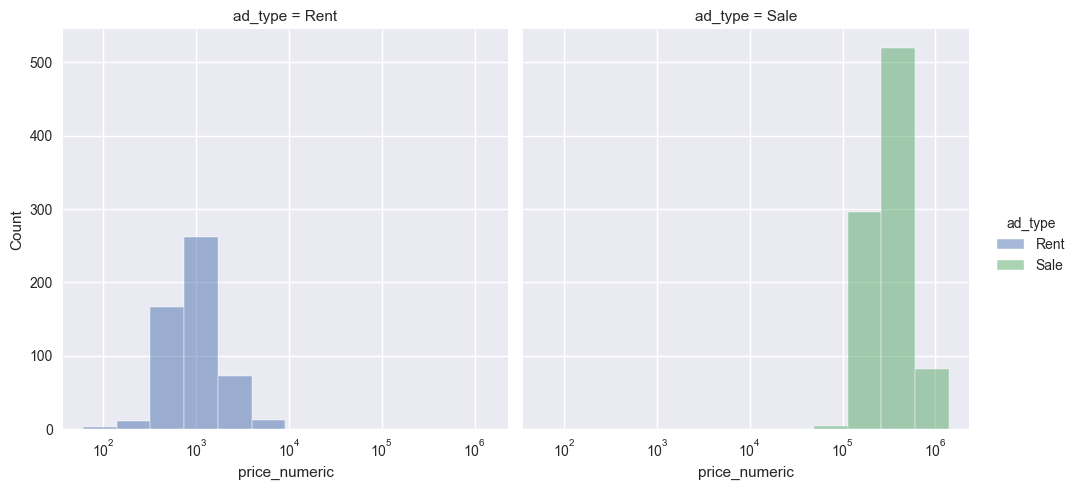

In [270]:
sns.displot(data=apartments, x="price_numeric", kind='hist', col='ad_type', log_scale=True, hue="ad_type")

<Axes: >

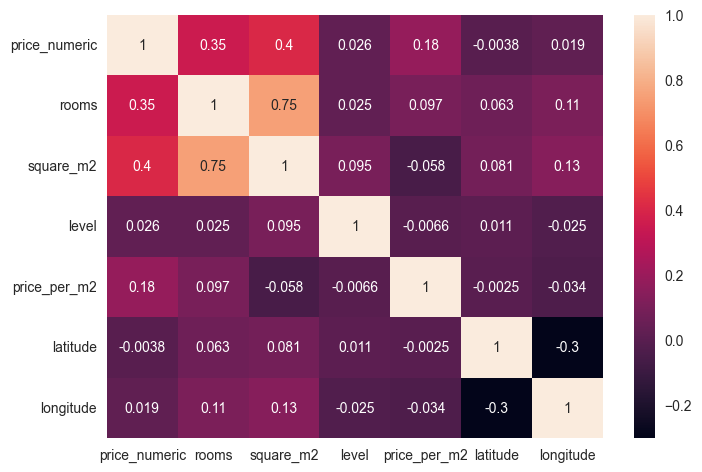

In [271]:
corr_matrix = apartments.corr(numeric_only=True)
sns.heatmap(data=corr_matrix, annot=True)

# Numerical Features Analysis

1. When it comes to `price_numeric` it seems that prices for `Rentals` are all concentrated around 0 and 1000000 which makes sense since renting prices don't go up to the prices that apartments go for when trying to be sold
2. When it comes to `square_m2` it seems to be a normal distribution for both `Rentals` and `Apartments on sale` which are very identical. We can expect the model to train well up to around 150 m2 for both `rentals` and `apartments on sale`
3. When it comes to `rooms` there are more listings for 2 and 3 rooms however even for the smallest one, 1 room, we have quite a nice number of entries so rooms shouldn't be a big problem when it comes to training
4. As predicted with the `level` feature the majority of apartments on sale are between 0 and 6, and there is a slight spike for apartments on sale for the value `20` but this is because we converted the `20+` to be just `20` which can include floors like 20, 21, and 22 (majority of bigger buildings are around 20 till 22 floors high)
5. `price_per_m2` seems to cluster the values nicely which does reduce the variance and could therefor be much easier problem for the ML model to predict

---
# Checking Missing Values

Now we will check some of the missing values that we have in the dataset

In [272]:
apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   price_numeric  1428 non-null   float64 
 1   municipality   1806 non-null   category
 2   condition      1806 non-null   category
 3   ad_type        1806 non-null   category
 4   property_type  1806 non-null   category
 5   rooms          1664 non-null   float64 
 6   square_m2      1806 non-null   float64 
 7   equipment      1806 non-null   category
 8   level          1806 non-null   int32   
 9   heating        1806 non-null   category
 10  price_per_m2   1428 non-null   float64 
 11  latitude       1175 non-null   float64 
 12  longitude      1175 non-null   float64 
dtypes: category(6), float64(6), int32(1)
memory usage: 103.9 KB


---
## Missing latitude / longitude

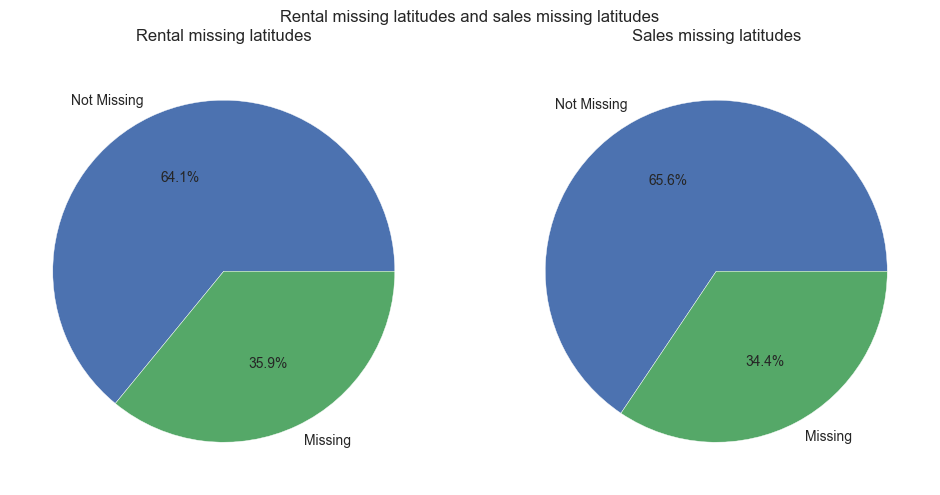

In [273]:
rentals_missing_latitudes = rentals['latitude'].isna().value_counts()
sales_missing_latitudes = sales['latitude'].isna().value_counts()

category_colors = {
  True : default_colors[1],
  False : default_colors[0],
}

category_labels = {
  True : 'Missing',
  False : 'Not Missing'
}

plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(x = rentals_missing_latitudes, labels=[category_labels[c] for c in rentals_missing_latitudes.index.values], autopct='%.1f%%', colors=[category_colors[c] for c in rentals_missing_latitudes.index.values])
plt.title('Rental missing latitudes', pad=12)

plt.subplot(1, 2, 2)
plt.pie(x = sales_missing_latitudes, labels=[category_labels[c] for c in sales_missing_latitudes.index.values], autopct='%.1f%%', colors=[category_colors[c] for c in sales_missing_latitudes.index.values])
plt.title('Sales missing latitudes', pad=12)

plt.suptitle('Rental missing latitudes and sales missing latitudes')
plt.tight_layout()

Text(0.5, 1.0, 'Number of apartments overall')

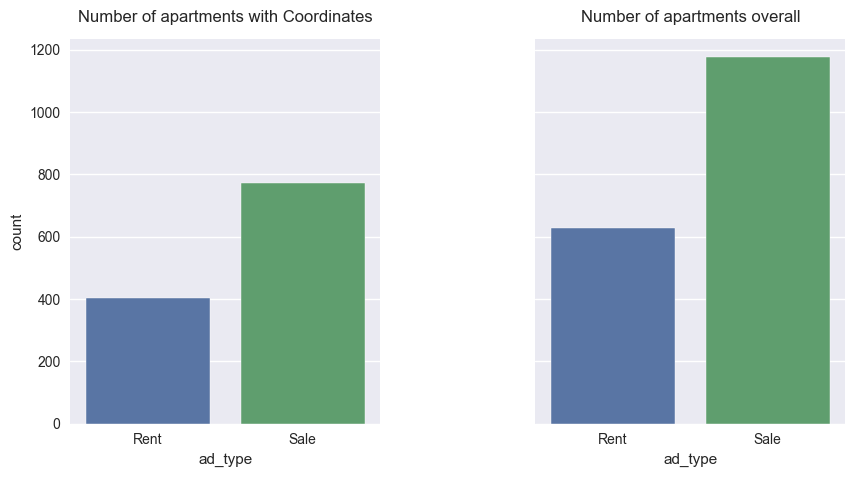

In [274]:
apartments_without_missing_lat_or_long = apartments[(apartments['latitude'].notna()) & (apartments['longitude'].notna())]


plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)
plt.subplots_adjust(wspace=0.5)

plt.subplot(1, 2, 1)
sns.countplot(data=apartments_without_missing_lat_or_long, x='ad_type',  hue='ad_type')
plt.title('Number of apartments with Coordinates', pad=12)

plt.subplot(1, 2, 2)
sns.countplot(data=apartments, x='ad_type',  hue='ad_type')
plt.title('Number of apartments overall', pad=12)



---
## Missing price

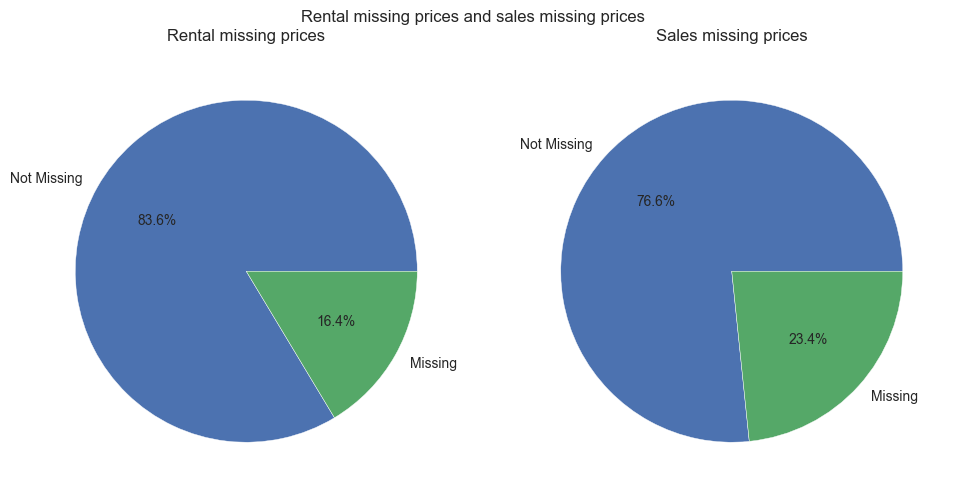

In [275]:
rentals_missing_price = rentals['price_numeric'].isna().value_counts()
sales_missing_price = sales['price_numeric'].isna().value_counts()

category_colors = {
  True : default_colors[1],
  False : default_colors[0],
}

category_labels = {
  True : 'Missing',
  False : 'Not Missing'
}

plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(x = rentals_missing_price, labels=[category_labels[c] for c in rentals_missing_price.index.values], autopct='%.1f%%', colors=[category_colors[c] for c in rentals_missing_price.index.values])
plt.title('Rental missing prices', pad=12)

plt.subplot(1, 2, 2)
plt.pie(x = sales_missing_price, labels=[category_labels[c] for c in sales_missing_price.index.values], autopct='%.1f%%', colors=[category_colors[c] for c in sales_missing_price.index.values])
plt.title('Sales missing prices', pad=12)

plt.suptitle('Rental missing prices and sales missing prices')
plt.tight_layout()

Text(0.5, 1.0, 'Number of apartments overall')

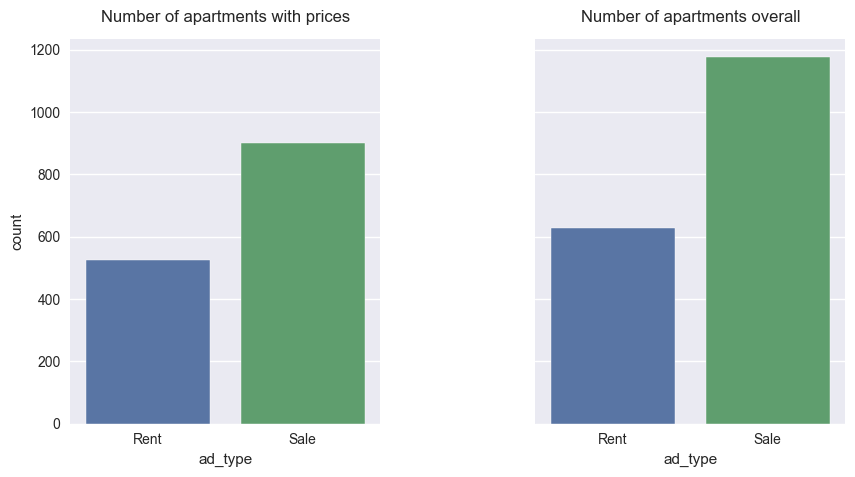

In [276]:
apartments_without_missing_price = apartments[apartments['price_numeric'].notna()]

plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)
plt.subplots_adjust(wspace=0.5)

plt.subplot(1, 2, 1)
sns.countplot(data=apartments_without_missing_price, x='ad_type',  hue='ad_type')
plt.title('Number of apartments with prices', pad=12)

plt.subplot(1, 2, 2)
sns.countplot(data=apartments, x='ad_type',  hue='ad_type')
plt.title('Number of apartments overall', pad=12)

---
## Missing rooms

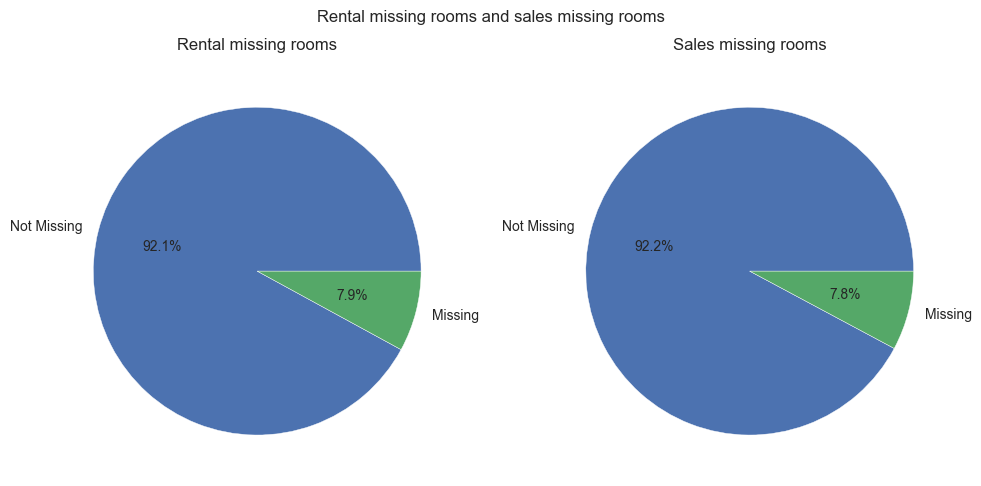

In [277]:
rentals_missing_room = rentals['rooms'].isna().value_counts()
sales_missing_room = sales['rooms'].isna().value_counts()

category_colors = {
  True : default_colors[1],
  False : default_colors[0],
}

category_labels = {
  True : 'Missing',
  False : 'Not Missing'
}

plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.pie(x = rentals_missing_room, labels=[category_labels[c] for c in rentals_missing_room.index.values], autopct='%.1f%%', colors=[category_colors[c] for c in rentals_missing_room.index.values])
plt.title('Rental missing rooms', pad=12)

plt.subplot(1, 2, 2)
plt.pie(x = sales_missing_room, labels=[category_labels[c] for c in sales_missing_room.index.values], autopct='%.1f%%', colors=[category_colors[c] for c in sales_missing_room.index.values])
plt.title('Sales missing rooms', pad=12)

plt.suptitle('Rental missing rooms and sales missing rooms')
plt.tight_layout()

Text(0.5, 1.0, 'Number of apartments overall')

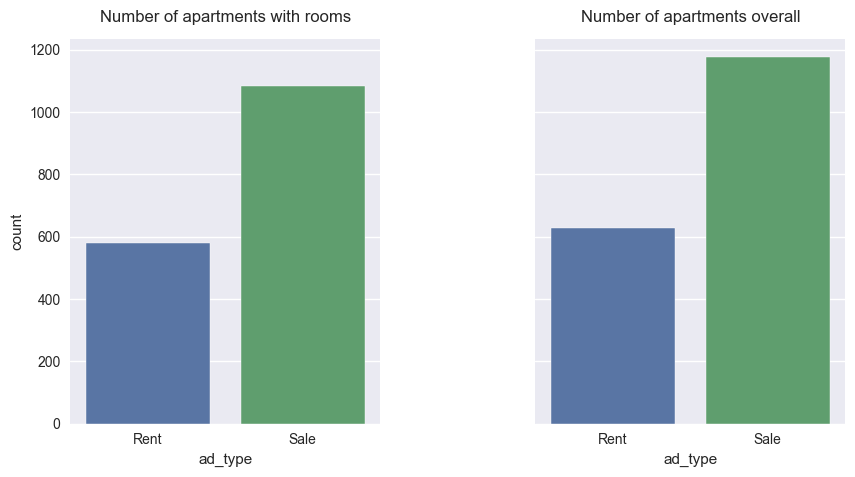

In [278]:
apartments_without_missing_room = apartments[apartments['rooms'].notna()]

plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)
plt.subplots_adjust(wspace=0.5)

plt.subplot(1, 2, 1)
sns.countplot(data=apartments_without_missing_room, x='ad_type',  hue='ad_type')
plt.title('Number of apartments with rooms', pad=12)

plt.subplot(1, 2, 2)
sns.countplot(data=apartments, x='ad_type',  hue='ad_type')
plt.title('Number of apartments overall', pad=12)

---
## Combinations of missing values

<Axes: title={'center': 'Non-Missing prices, coordinates, and rooms'}, xlabel='ad_type', ylabel='count'>

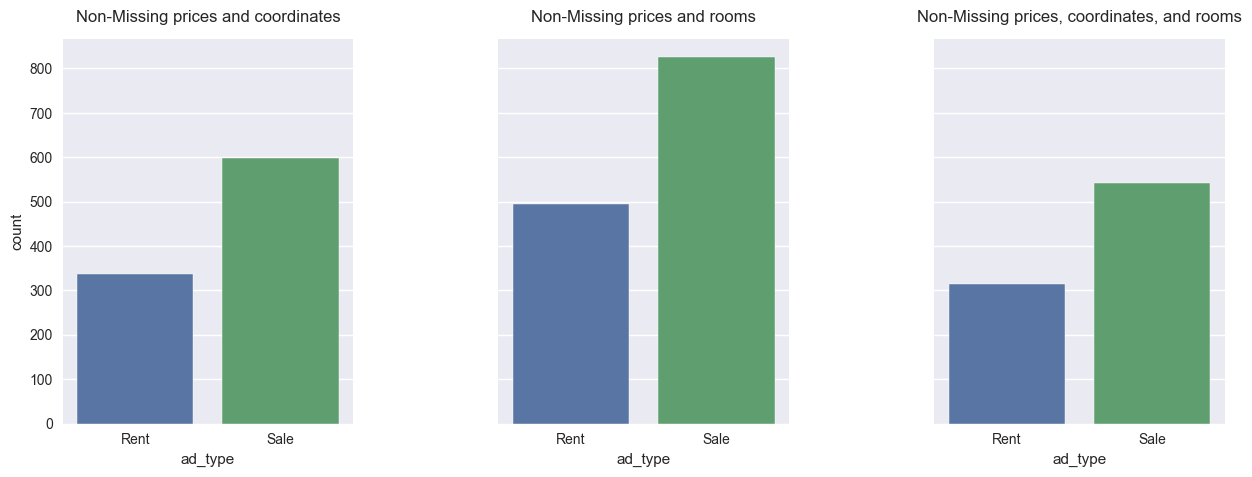

In [279]:
missing_prices_and_cords = apartments[(apartments['price_numeric'].notna()) & (apartments['latitude'].notna()) & (apartments['longitude'].notna())]
missing_prices_and_rooms = apartments[(apartments['rooms'].notna()) & (apartments['price_numeric'].notna())]
missing_prices_rooms_and_cords = apartments[(apartments['price_numeric'].notna()) & (apartments['rooms'].notna()) & (apartments['latitude'].notna()) & (apartments['longitude'].notna())]

plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)
plt.subplots_adjust(wspace=0.5)

plt.subplot(1,3,1)
plt.title('Non-Missing prices and coordinates', pad=12)
sns.countplot(data=missing_prices_and_cords, x='ad_type', hue='ad_type')

plt.subplot(1,3,2)
plt.title('Non-Missing prices and rooms', pad=12)
sns.countplot(data=missing_prices_and_rooms, x='ad_type', hue='ad_type')

plt.subplot(1,3,3)
plt.title('Non-Missing prices, coordinates, and rooms', pad=12)
sns.countplot(data=missing_prices_rooms_and_cords, x='ad_type', hue='ad_type')



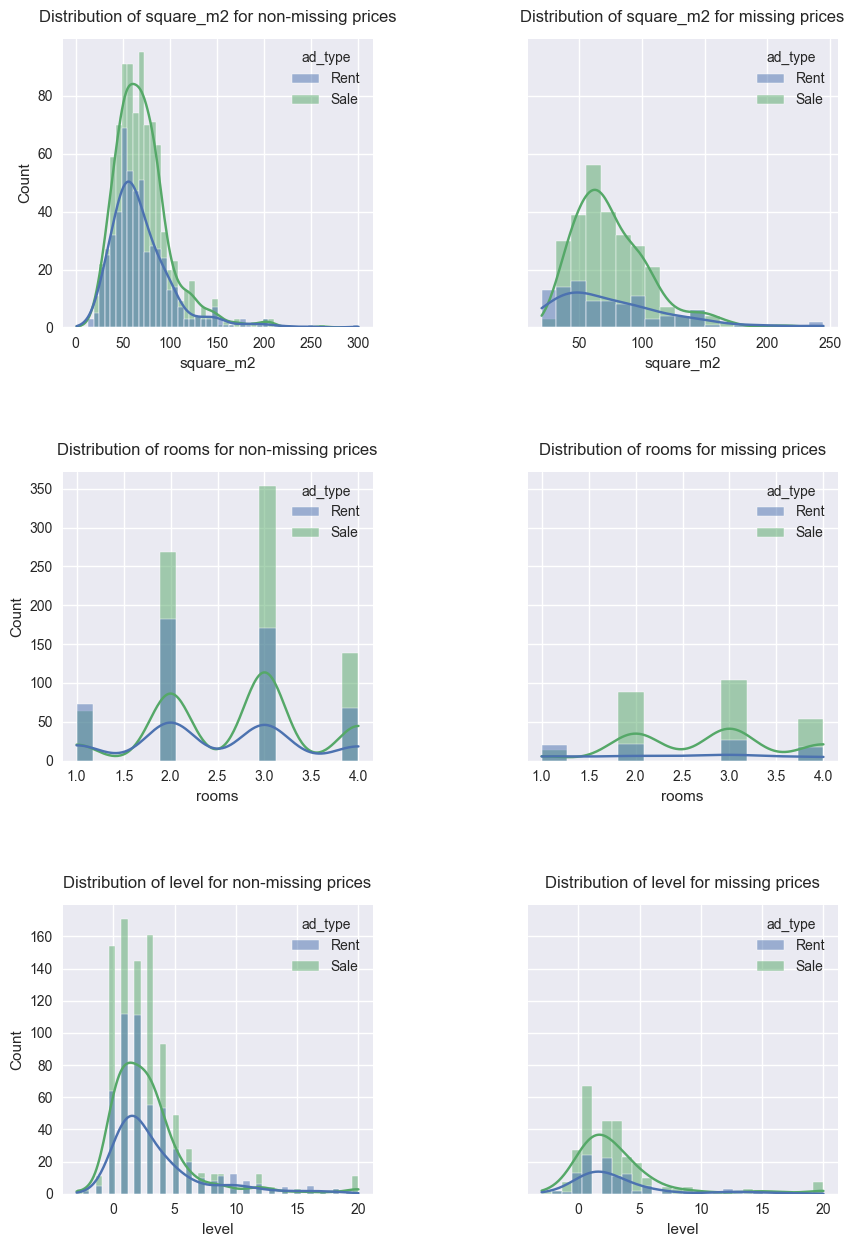

In [280]:
non_missing_prices = apartments[apartments['price_numeric'].notna()]
missing_prices = apartments[apartments['price_numeric'].isna()]

numeric_features_set = set(numeric_features)
numeric_features_set -= {"price_numeric", "price_per_m2"}
num_of_features = len(numeric_features_set)

plt.subplots(nrows=num_of_features, ncols=2, figsize=(10, 5*len(numeric_features_set)), sharey="row")
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for index, feat in enumerate(numeric_features_set):
  plt.subplot(num_of_features, 2, 1 + 2*index)
  plt.title(f"Distribution of {feat} for non-missing prices", pad=12)
  sns.histplot(data=non_missing_prices, x=feat, hue='ad_type', kde=True)

  plt.subplot(num_of_features, 2, 2*(index + 1))
  plt.title(f"Distribution of {feat} for missing prices", pad=12)
  sns.histplot(data=missing_prices, x=feat, hue='ad_type', kde=True)


## Conclusion about missing data

1. When it comes to apartment listings with missing prices, imputing a summary statistic such as the median (or mean) price may be acceptable if the missing and non-missing prices follow similar distributions. However, for rental listings this approach is less appropriate, as the distributions of listings with missing prices differ noticeably from those with observed prices. In such cases, simple global imputation would likely introduce bias.
2. One thing that could be done is `group-based imputation` but at the same time removing the apartments with missing prices still leaves a lot of data which we can work with
3. The *coordinates* `(latitude,longitude)` is more problematic because they are just so many missing values. And even from all the values we do have, not all of them relate to the location of the apartments rather they relate to the sellers location
4. When it comes to `rooms` there are some missing values but not by much and as can be seen we still have over **1000** entries if we were to remove both entries with missing `prices` and `rooms`
5. Overall I think it is worth to both try `group-based imputation` for the `price` feature and removal of entries that have `price` missing. And to drop the coordinates features and to drop entries with missing rooms even thought they could also be imputed to around 2.5 since the majority of apartments have around two to three rooms with exception that rentals tend to have more one-room apartments.

---
# Cleaning up and final analysis

## Removing un-needed features and dropping entries with rare values

<Axes: >

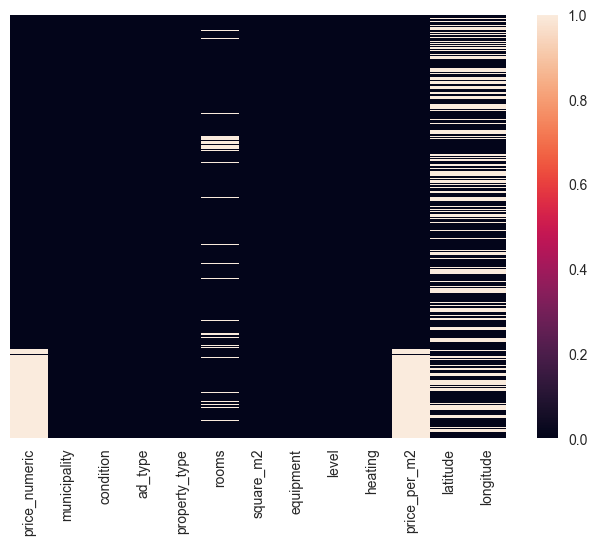

In [281]:
sns.heatmap(apartments.isnull(), vmin=0, vmax=1, yticklabels=False)

In [282]:
indexes_of_bad_condition = apartments[ apartments[ 'condition' ] == 'Apartment' ].index.values
apartments.drop(labels=indexes_of_bad_condition, axis="index", inplace=True) # Drop the outlier where someone noted the condition of their apartment to be 'apartment'


In [283]:
apartments.drop(labels="property_type", axis="columns", inplace=True) # Drop property type as it isn't an important feature

In [284]:
apartments.drop(labels=["latitude", "longitude"], axis="columns", inplace=True) # Drop the coordinates as they aren't important

In [285]:
apartments.dropna(axis="index", how="any", subset=["price_numeric", "rooms"], inplace=True) # Drop entries with missing prices and or rooms

<Axes: >

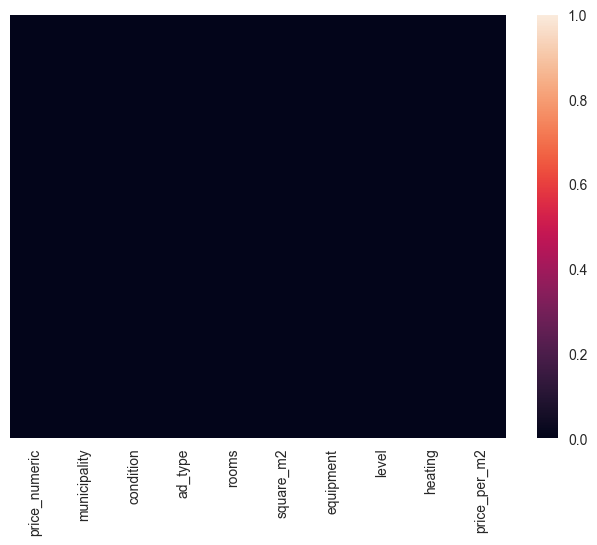

In [286]:
sns.heatmap(apartments.isnull(), vmin=0, vmax=1, yticklabels=False)


In [287]:
index_of_Ilijas = apartments['municipality'] == 'Ilijaš'
index_of_Hadzici = apartments['municipality'] == 'Hadžići'
apartments.drop(labels=apartments[index_of_Ilijas | index_of_Hadzici | index_of_wood_heating].index.values, axis="index", inplace=True) # Remove Ilijas and Hadzici because of low data

In [288]:
rentals_that_need_renovation = apartments[(apartments['condition'] == 'Needs Renovation') & (apartments['ad_type'] == 'Rent')].index.values
apartments.drop(labels=rentals_that_need_renovation, axis="index", inplace=True) # Remove rentals that are marked as needing renovations

In [289]:
apartments.replace(to_replace={'heating' : {'Wood Heating' : 'Other'}}, inplace=True) # Move Wood Heating to Other

/var/folders/0c/_nswk8qx52s9mwd15r_1fzy80000gn/T/ipykernel_7607/3381618698.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  apartments.replace(to_replace={'heating' : {'Wood Heating' : 'Other'}}, inplace=True) # Move Wood Heating to Other


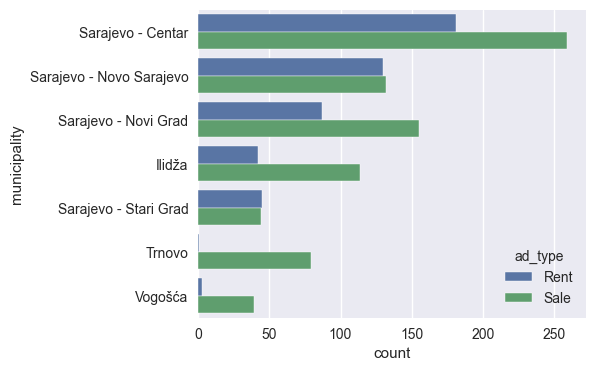

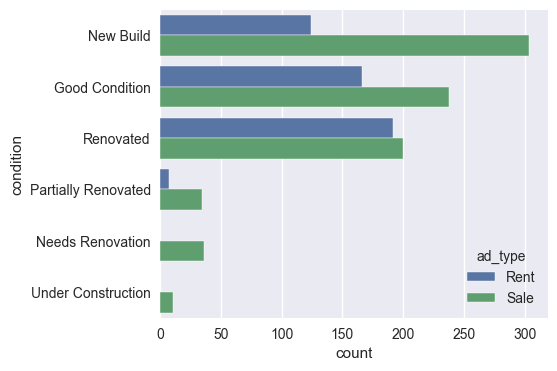

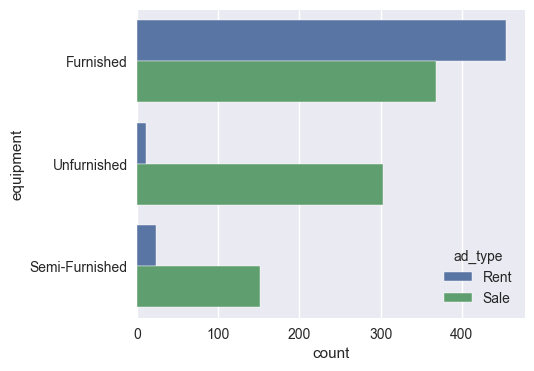

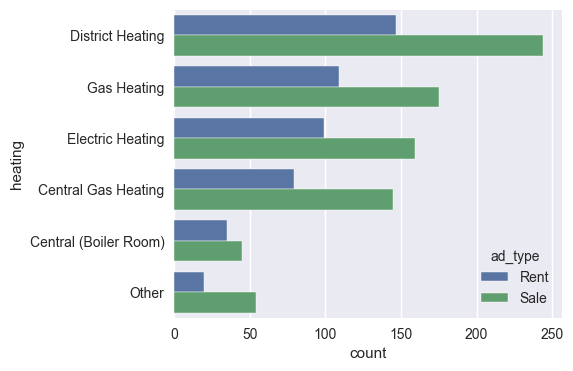

In [290]:
for column, column_type in apartments.dtypes.items():
  if column_type  == 'category' and column != 'ad_type':
    apartments[column] = apartments[column].cat.remove_unused_categories()

    plt.figure(figsize=(5, 4))
    sns.countplot(data=apartments, y = column, order=apartments[column].value_counts().index.values, hue="ad_type")


---
# Prepping up the dataset

In [303]:
rentals = apartments[apartments['ad_type'] == 'Rent'].drop(labels='ad_type', axis='columns')
sales = apartments[apartments['ad_type'] == 'Sale'].drop(labels='ad_type', axis='columns')

rentals.to_csv("../data/rentals.csv", index=False)
sales.to_csv("../data/sales.csv", index=False)